# Chapter-05. 文本匹配
## 【章节目标】
- 了解文本匹配含义
- 掌握传统的文本相似度计算方式
- 掌握基于深度学习的文本语义匹配

## 【章节内容】
### 5.1 文本匹配概述
#### 5.1.1 文本匹配概念
文本匹配主要研究计算两段文本的相似度问题。相似度问题包含两层：

- 一是两段文本如何表示可使得计算机方便处理，这需要研究不同的表示方法效果的区别;
- 二是如何定义相似度来作为优化目标，如语义匹配相似度、点击关系相似度、用户行为相似度等，这和业务场景关系很紧密。

**文本匹配技术演进**

- 文本的表示和匹配是本节的主线，如何做到语义层面匹配就成为本节的主旨：
- 受到整体技术的演进影响，文本的匹配技术同样有一个顺应时代的技术历程，如图所示:

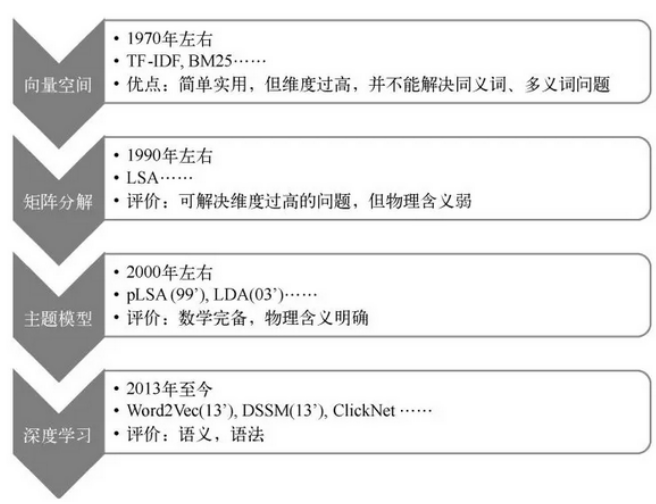

#### 5.1.2 文本匹配中的文本语义表示
**文本语义表示方法：**

- 向量空间
- 矩阵分解(LSA)
- 主题模型(PLSA、LDA)
- 基于深度学习的文本语义表示


**1.向量空间：**

- 1970年左右提出的向量空间模型，就是把文档表示词表维度的向量通过TF-IDF计算出词的权重，比如一种标准词表包含词ID、词和IDF，另一种是停用词表:

- 例如：对文本“丽江的酒店价格”分词去除停用词后，得到丽江、酒店、价格，词出现次数是1，查表IDF得到这句文本的表示：[0, 1.5, 2.1, 0, 0, …, 0, 4.1]。其中权重使用的是TF×IDF，TF是Term在文本里的频次，IDF是逆文档频次，两者定义有很多形式。

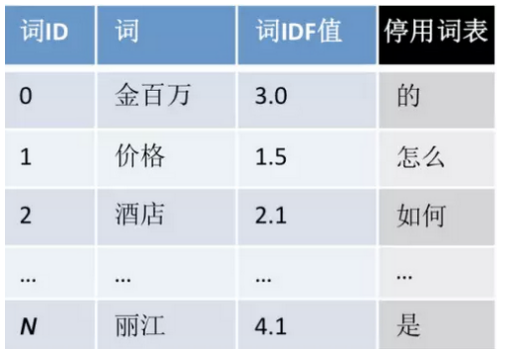  
计算TF-IDF向量需要使用的词表

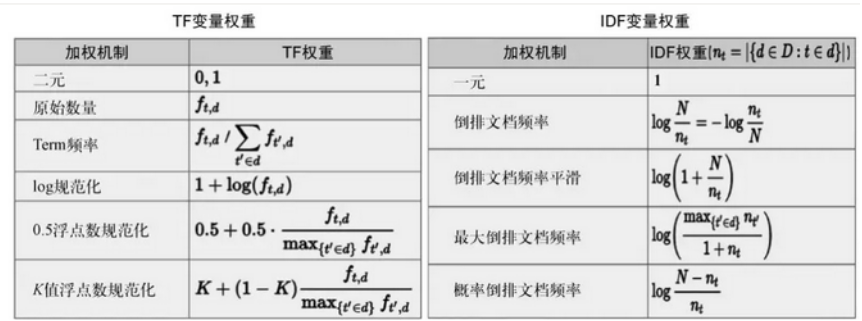  
各种不同的计算tfidf的方法

**2.矩阵分解：**

- 向量空间模型的高维度对语义信息刻画不好，文档集合会表示成高维稀疏大矩阵。1990年左右，有人研究通过矩阵分解的方法，把高维稀疏矩阵分解成两个狭长小矩阵，而这两个低维矩阵包含了语义信息，这个过程即潜在语义分析:

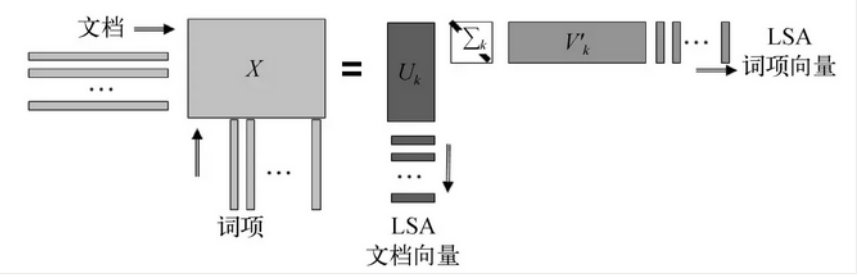  
使用svd矩阵分解技术讲文档-词矩阵分解为文档向量矩阵和词向量矩阵

**3.主题模型 pLSA（Probabilistic Latent Semantic Analysis）：**

- pLSA在潜在语义分析之上引入了主题概念。它是一种语义含义，对文档的主题建模不再是矩阵分解，而是概率分布（比如多项式分布），这样就能解决多义词的分布问题，并且主题是有明确含义的。但这种分析的基础仍然是文档和词的共现频率，分析的目标是建立词/文档与这些潜在主题的关系，而这种潜在主题进而成为语义关联的一种桥梁。这种转变过渡可如图所示:

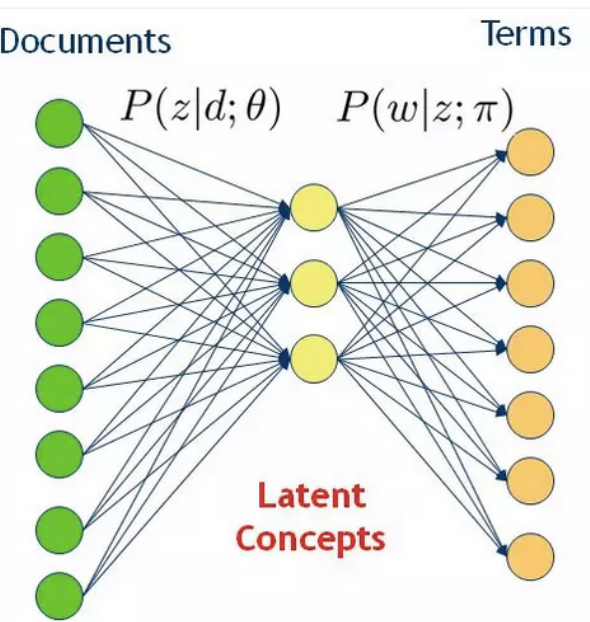  
PLSA模型的隐语义  
- 假设每篇文章都由若干主题构成，每个主题的概率是p(z∣d)，在给定主题的条件下，每个词都以一定的概率p(w∣z)产生。这样，文档和词的共现可以用一种产生式的方式来描述：

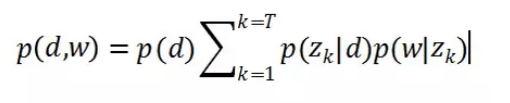  
PLSA模型的文本生成方式

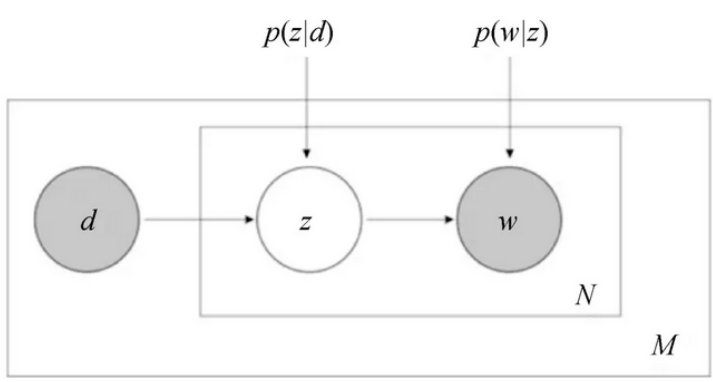  
可以通过EM算法把$p(z|d)$和$p(w|z)$作为参数来学习,需要学习的$p(z|d)$参数数目是主题数和文档数乘的关系，$p(w|z)$是词表数乘主题数的关系

**4.主题模型 LDA（Latent Dirichlet Allocation）：**

- 如果说pLSA是频度学派代表，那LDA就是贝叶斯学派代表。LDA通过引入Dirichlet分布作为多项式共轭先验，在数学上完整解释了一个文档生成过程，其概率图模型如图所示。：
- 和pLSA概率图模型不太一样，LDA概率图模型引入了两个随机变量α和β，它们就是控制参数分布的分布，即文档-主题符合多项式分布。这个多项式分布的产生受Dirichlet先验分布控制，可以使用变分期望最大化（Variational EM）和吉布斯采样（Gibbs Sampling）来推导参数，这里不展开叙述

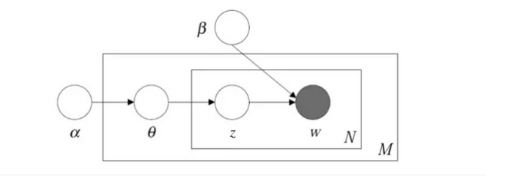  
LDA概率图模型

**5.基于深度学习的文本语义表示：**

- 传统的搜索文本相关性模型，如BM25通常计算Query与Doc文本term匹配程度。由于Query与Doc之间的语义gap, 可能存在很多语义相关，但文本并不匹配的情况。为了解决语义匹配问题，出现很多LSA，LDA等语义模型。随着深度学习在NLP的应用，在IR和QA(问答系统)中出现了很多深度模型将query和doc通过神经网络embedding，映射到一个稠密空间的向量表示，然后再计算其是否相关，并取得很好的效果:
- DSSM、CDSSM，LSTM-DSSM，DRMM，MatchPyramid

#### 5.1.3 文本相似度问题
**文本相似度问题：**

- 文本相似度问题包含：词与词、句与句、段落与段落、篇章与篇章之间的相似度问题；以及词与句、句与段落、段落与篇章等之类的相似度问题，这里的相似指的是语义的相似。这些问题的难度递增:

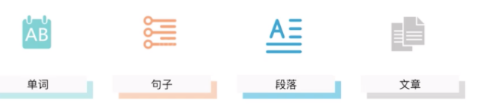  
文本语义级别

**文本相似度计算方法：**

- 有监督方法，就是用朴素贝叶斯分类器之类的有监督模型来判断文本相似性或者计算相似度。
    - 这类方法要求有一定数量的标注语料，构建的代价比较高；
    - 由于训练语料通常无法做得很大，模型的泛化性不够，实际用起来会有点麻烦；
    - 距离计算环节的复杂度会比较高。
- 无监督方法，就是用欧氏距离等方法，直接计算文本之间的距离或者相似度。这类方法的特点是：
    - 不需要标注语料，特征工程或者参数估计可以使用很大的数据；
    - 很多方法对语言的依赖比较小，可以应对多语种混杂的场景；
    - 距离计算环节复杂度较低。

#### 5.1.4 文本相似度应用
**搜索系统**

- 利用query来搜索最相关的文本/网页。
- 利用网页的标题、内容等信息。

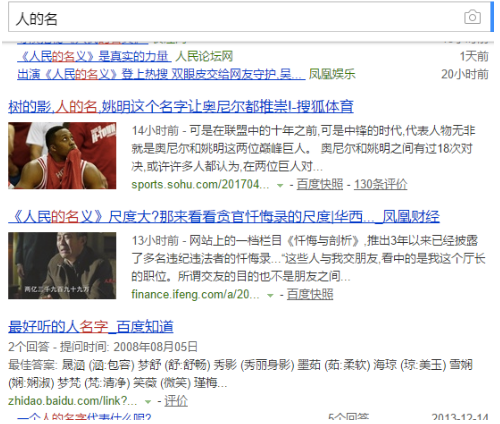

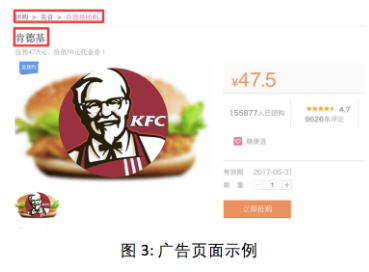

**问答系统**

- 用户提问的问题与语料库中的问题进行相似度匹配，选择相似度最高的问题的答案作为回答
- 智能客服

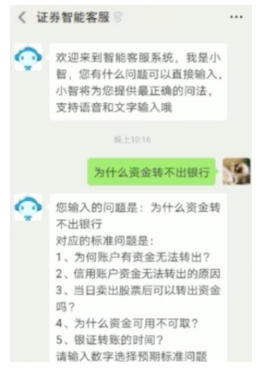

**新闻个性化推荐**

- 在互联网应用中，当我们积累了用户大量的行为信息后，这些行为信息对应的文本内容可以组合成一篇抽象的“文档”，对该“文档”进行主题映射 后获得的 主题分布 作为用户画像

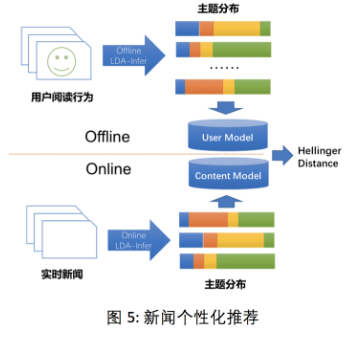

#### 5.1.5 文本相似度计算方法
**推荐和搜索的本质**

推荐和搜索的本质其实都是匹配，前者匹配用户和物品；后者匹配 query 和 doc。

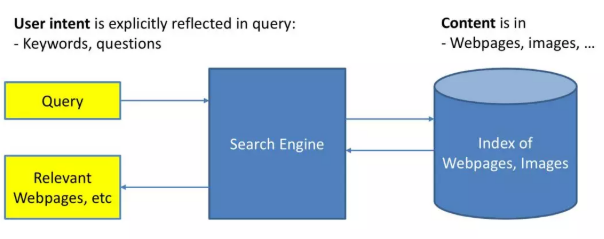  
> 对于搜索来说，搜索引擎的本质是对于用户给定query，搜索引擎通过 query-doc 的 match 匹配，返回用户最可能点击的文档的过程。从某种意义上来说，query
代表的是一类用户，就是对于给定的query，搜索引擎要解决的就是 query和doc 的 match 。

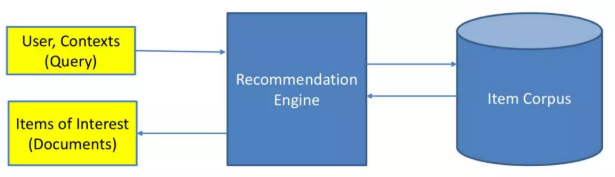  
> 对于推荐来说，推荐系统就是系统根据用户的属性 ( 如性别、年龄、学历等 )，用户在系统里过去的行为 ( 例如浏览、点击、搜索、收藏等 )，以及当前上下文环境 ( 如网络、手机设备等 )，从而给用户推荐用户可能感兴趣的物品 ( 如电商的商品、feeds 推荐的新闻、应用商店推荐的 app 等 )，从这个过程来看，推荐系统要解决的就是 user 和 item 的 match 。

**匹配方法分类**

- 具体到匹配方法，分为传统模型和深度模型两大类。本章系统的介绍传统模型和深度模型，以及语义匹配和相关性匹配：
- 传统文本相似度计算：编辑距离，余弦距离，simhash，bm2.5
- 基于深度学习的文本语义匹配：匹配的文本具有同质性
- 基于深度学习的文本相关性匹配：匹配的文本异质（一长一短，问题-答案）

### 5.2 传统文本相似度计算
#### 5.2.1 传统文本相似度计算方法
传统文本相似度计算方法：

- 编辑距离(Edit Distance)
- 杰卡德相似度 Jaccard Similarity
- 欧氏距离相似度
- 余弦相似度
- 海明距离
- SimHash
- BM25

#### 5.2.2 编辑距离
**编辑距离(Edit Distance):**

- 又称Levenshtein距离,是指两个字串之间,由一个转成另一个所需的最少编辑操作次数。即给定两段文本或两个句子，最少需要经过多少步操作能够从一个句子转化为另一个句子。允许的操作有：

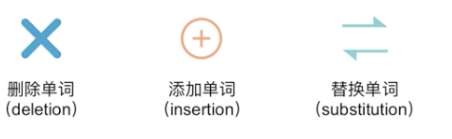  
允许的操作

**利用动态规划解决编辑距离：**

- 假设我们比较kitten和sitting这两个单词的相似度(此时操作的基本单位是字符，如果是句子/段落相似度问题的话，基本操作单位就是单词)。
- 利用动态规划的思想，计算两个字符串的编辑距离，就相当于计算他们子串的编辑距离，再加上从子串到全串需要的最少操作数即可，不断的进行递推。递推公式如下:
$$
\operatorname{lev}_{a,b}(i,j) =
\begin{cases}
\max(i,j), & \text{if } \min(i,j) = 0 \\
\min
\begin{cases}
\operatorname{lev}_{a,b}(i-1,j) + 1 \\
\operatorname{lev}_{a,b}(i,j-1) + 1 \\
\operatorname{lev}_{a,b}(i-1,j-1) + \mathbf{1}(a_i \ne b_j)
\end{cases}, & \text{otherwise}
\end{cases}
$$

动态规划递推计算

**生成编辑距离矩阵：**

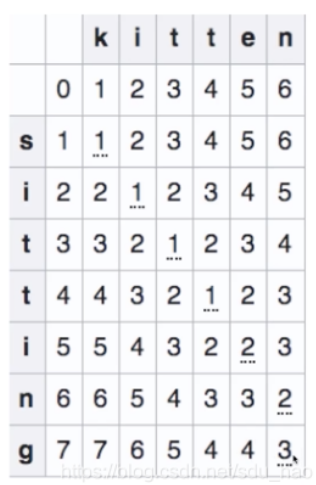

- 1）kitten和siting都是从第一个位置开始，$\operatorname{lev}_{a,b}(i,j) = 0$
    - 如果 i = 0 或 j = 0，即第0行或第0列，$\operatorname{lev}_{a,b}(i,j) = \max(i,j)$
- 2）当i,j都不为0时 $lev_{a, b}(i, j)= min{lev_{a, b}(i-1, j)+1,lev_{a, b}(i, j-1)+1,lev_{a, b}(i-1, j-1)(if a_i= b_j),lev_{a, b}(i, j)+1(ifa_i≠b_j)}$
- 3） 矩阵右下角的3，就是字符串kitten和sitting的编辑距离，即相似度;其斜上方的3，就是子串kitte和siti的编辑距离，即相似度。
- 4） 当矩阵的第一行和第一列都初始化后、每个子串的编辑距离，都基干其斜上，上和左边的编辑距离通过3）中的公式来计算。比如，看上述矩阵的第四行第六列，它是子串kitt和si的编辑距离 为3.当计算这个值时，首先看斜上方、即kit和s的编辑距离为3，由于4;≠b即t和i不同，所以通过3）中的公式计算可得3+1=4;再看上方，即kitt和s的编辑距离为3，kitt和si编辑距离可以通过一步添加操作得到，通过3）中的公式计算可得3+1=4;再看左方，即kit和si的编辑距离为2. kitt和si编辑距离可以通过一步添加操作得到，通过3）中的公式计算可得2+1=3。取三者的最小值，最终kitt和si的编辑距离为3。

**实战：基于Python实现编辑距离**

In [1]:
def editDistDP(s1, s2):
    m = len(s1)
    n = len(s2)
    # 创建一张表格记录所有子问题的答案
    dp = [[0 for x in range(n+1)] for x in range(m+1)]

    # 从上往下填充DP表格
    for i in range(m+1):
        for j in range(n+1):
            # 如果第一个字符串为空，唯一的编辑方法就是添加第二个字符串
            if i == 0:
                dp[i][j] = j # Min. operations = j 
            
            # 如果第二个字符串为空，唯一的方法就是删除第一个字符串中的所有字母
            elif j == 0:
                dp[i][j] = i # Min. operations = i 
            
            # 如果两个字符串结尾字母相同，我们就可以忽略最后的字母
            elif s1[i-1] == s2[j-2]:
                dp[i][j] = dp[i-1][j-1]
            
            # 如果结尾字母不同，那我们就需要考虑三种情况，取最小的编辑距离
            else:
                dp[i][j] = 1 + min(dp[i][j-1], # 添加
                                   dp[i-1][j], # 删除
                                   dp[i-1][j-1]) # 替换
    return dp[m][n]

s1 = "natural language processing is a promising research area"
s2 = "more researchers are working on natural language processing nowadays"

editDistDP(s1.split(), s2.split()) #输入为两个句子 以词为单位 .split() 空格切分。汉语需要jieba分词。

9

#### 5.2.3 杰卡德相似度 Jaccard Similarity
- 杰卡德相似度一般被用来度量两个集合之间的差异大小。假设我们有两个集合A和B，那么二者的杰卡德相似度为：
$$\text{similarity} = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{len}(A \ \text{and} \ B)}{\text{len}(A \ \text{or} \ B)}$$
- 杰卡德距离的思想非常简单:
    - 两个集合共有的元素越多，二者越相似；
    - 为了控制距离的取值范围，我们可以增加一个分母，也就是两个集合拥有的所有元素

**基于杰卡德相似度的文本相似度计算：**

- 我们可以把文档看做是词语的集合,然后用杰卡德距离相似度度量文档之间的差异。

> 缺点：只考虑单词出现与否，忽略每个单词的含义，忽略单词顺序，没有考虑单词出现的次数

#### 5.2.4 欧氏距离相似度
**欧氏距离的计算方法：**

- 假设我们有两个数值向量,表示两个实例在欧式空间中的位置:
$$ A = (a_1, a_2, \dots, a_i, \dots, a_N) $$
$$ B = (b_1, b_2, \dots, b_i, \dots, b_N) $$
$$\text{distance} = \sqrt{(A - B)(A - B)^T} = \sqrt{\sum_{i=1}^{N} (a_i - b_i)^2}$$
欧氏距离公式

**基于欧式距离的文本相似度计算：**

- 假设我们的词汇表是:
- 那么两个句子对应的TF向量(实际可采用TFIDF向量)分别是:
$$\text{vec}_3 = (1, 1, 1, 1, 0, 1)$$ $$\text{vec}_4 = (1, 1, 1, 1, 1, 0)$$
- 二者的欧氏距离为:
$$\text{distance} = \sqrt{(1-1)^2 + (1-1)^2 + (1-1)^2 + (1-1)^2 + (0-1)^2 + (1-0)^2} = \sqrt{2}$$
- 这样，我们就可以计算相似度了，常用的方式是:
$$\text{similarity} = \frac{1}{\text{distance} + 0.001} = \frac{1}{\sqrt{2} + 0.001}$$

#### 5.2.5 余弦相似度
**余弦相似性通过测量两个向量的夹角的余弦值来度量它们之间的相似性**

- 两个向量间的余弦值可以通过使用欧几里得点积公式求出:
$$\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\| \, \|\mathbf{b}\| \cos \theta$$
- 给定两个属性向量，A和B，其余弦相似性θ由点积和向量长度给出，如下所示:
$$\text{similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \, \|\mathbf{B}\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \, \sqrt{\sum_{i=1}^{n} B_i^2}}$$
- 给出的相似性范围从-1到1：-1意味着两个向量指向的方向正好截然相反，1表示它们的指向是完全相同的，0通常表示它们之间是独立的，而在这之间的值则表示中间的相似性或相异性

**余弦相似性通过测量两个向量的夹角的余弦值来度量它们之间的相似性**

- 在文本相似度计算任务中，为了让数据适合余弦夹角的概念，人们假想：语义空间中存在一个“原点”；以原点为起点、文本特征数组(这里为了避免与“语义向量”混淆，借用了“数组”这个名称)表示的点为终点 ，构成了一个向量，这就是代表了文本语义的“语义向量”。语义向量的方向，描述了文本的语义。因此，我们可以用两篇文档的语义向量的夹角余弦值来表示它们的差异。这个余弦值通常被称为“余弦相似度”

- 当文本特征维度比较高的时候，在余弦距离的视角下，文本之间的区分度越来越小。

- 这导致我们在设定“是否相同”的阈值时，遇到困难。因此余弦距离比较适用于文本较短，也就是特征维度较低的场景。
$$\mathbf{v}_3 = (1,1,1,1,0,1)$$
$$\mathbf{v}_4 = (1,1,1,1,1,0)$$
$$
\cos = \frac{1\cdot1 + 1\cdot1 + 1\cdot1 + 1\cdot1 + 0\cdot1 + 1\cdot0}{\sqrt{1^2+1^2+1^2+1^2+0^2+1^2} \cdot \sqrt{1^2+1^2+1^2+1^2+1^2+0^2}} = \frac{4}{\sqrt{5}\cdot\sqrt{5}} = \frac{4}{5}
$$

#### 5.2.6 海明距离
我们比较两篇文档的特征向量的每一个维度，判断各个维度上取值是否相等。不相等的维度越多，两篇文档差异越大。海明距离的计算方式如下:

$$
\text{distance} = \sum_{i=1}^{N} r_i,\quad
r_i =
\begin{cases}
1, & \text{if } a_i \ne b_i \\
0, & \text{if } a_i = b_i
\end{cases}
$$

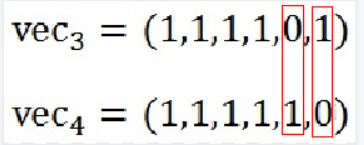  
两者的距离为2(实际还要归一化)

#### 5.2.7 SimHash
**SimHash原理**

- SimHash在搜索引擎中使用比较广泛，当你对关键词进行搜索后，会返回相关的一系列网页，但是互联网上的网页有很多都是高度重复的，所以一个高质量的返回结果，应该不同的，我们不希望返回结果中，前十个网页都是一样的。可以比较一下他们之间的Simhash，返回不同的内容。

**SimHash步骤：**

- 1.分词
- 2.提取关键词及权重
- 3.hash
- 4.hash加权
- 5.求和
- 6.符号降维

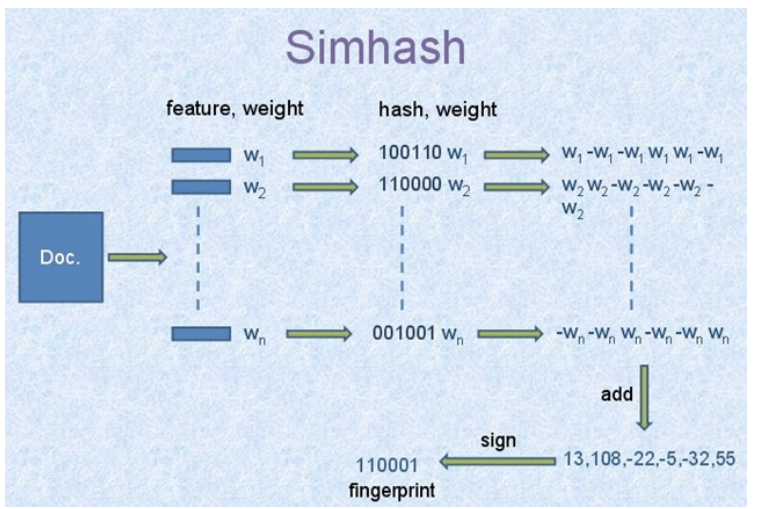

**SimHash计算示例：**

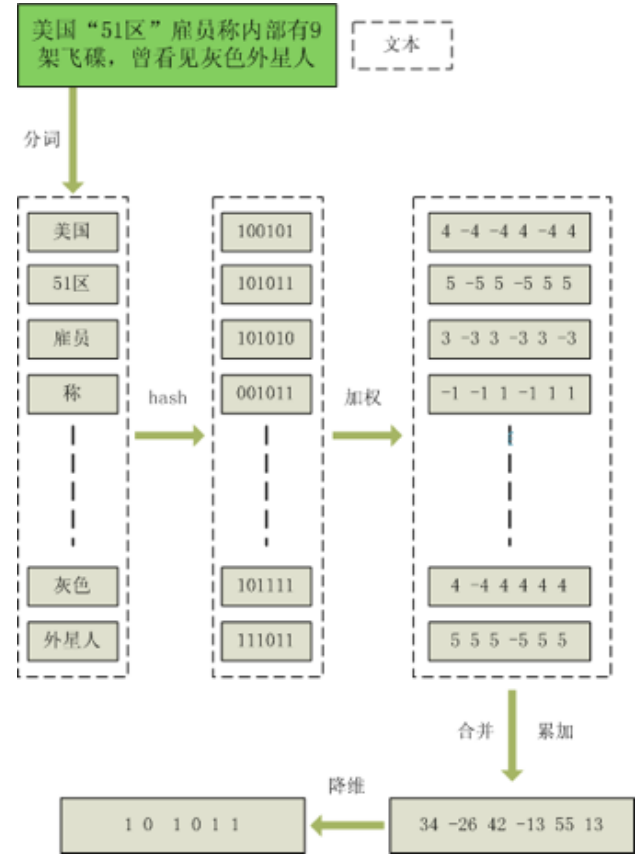

- 1、分词，把需要判断文本分词形成这个文章的特征单词。最后形成去掉噪音词的单词序列并为每个词加上权重，我们假设权重分为5个级别（1~5）。比如：“ 美国“51区”雇员称内部有9架飞碟，曾看见灰色外星人 ” ==> 分词后为 “ 美国（4） 51区（5） 雇员（3） 称（1） 内部（2） 有（1） 9架（3） 飞碟（5） 曾（1） 看见（3） 灰色（4） 外星人（5）”，括号里是代表单词在整个句子里重要程度，数字越大越重要。
- 2、hash，通过hash算法把每个词变成hash值，比如“美国”通过hash算法计算为 100101,“51区”通过hash算法计算为 101011。这样我们的字符串就变成了一串串数字，还记得文章开头说过的吗，要把文章变为数字计算才能提高相似度计算性能，现在是降维过程进行时。
- 3、加权，通过 2步骤的hash生成结果，需要按照单词的权重形成加权数字串，比如“美国”的hash值为“100101”，通过加权计算为“4 -4 -4 4 -4 4”；“51区”的hash值为“101011”，通过加权计算为 “ 5 -5 5 -5 5 5”。
- 4、合并，把上面各个单词算出来的序列值累加，变成只有一个序列串。比如 “美国”的 “4 -4 -4 4 -4 4”，“51区”的 “ 5 -5 5 -5 5 5”， 把每一位进行累加， “4+5 -4+-5 -4+5 4+-5 -4+5 4+5” ==》 “9 -9 1 -1 1 9”。这里作为示例只算了两个单词的，真实计算需要把所有单词的序列串累加。
- 5、降维，把4步算出来的“9 -9 1 -1 1 9” 变成 0 1 串，形成我们最终的simhash签名。 如果每一位大于0 记为 1，小于0 记为 0。最后算出结果为：“1 0 1 0 1 1”。

**代码实现**

In [2]:
import jieba
import jieba.analyse
import numpy as np

class SimHash(object):
    def simHash(self, content):
        seg = jieba.cut(content) # 分词
        jieba.analyse.set_stop_words('Dataset/IR/stopwords.txt') # 载入停用词
        # jieba基于TF-IDF提取关键词
        keyWords = jieba.analyse.extract_tags("|".join(seg), topK=10, withWeight=True) # 提取关键词

        keyList = []
        for feature, weight in keyWords: # 遍历每一个词
            print('weight: {}'.format(weight))
            weight = int(weight) # 权重调整
            binstr = self.string_hash(feature) # 进行hash
            temp = []
            for c in binstr: # 1 为正 0 为负
                if c == '1':
                    temp.append(weight)
                else:
                    temp.append(-weight)
            keyList.append(temp)
        listSum = np.sum(np.array(keyList), axis = 0) # 权重按列求和
        if keyList == []:
            return '00'
        simhash = ''.join(np.where(listSum>0, 1, 0).astype(str)) # 计算最终编码
        return simhash
    
    def string_hash(self, source): # 实现hash
        if source == "":
            return 0
        else:
            x = ord(source[0]) << 7
            m = 1000003
            mask = 2**128 - 1
            for c in source:
                x = ((x*m)^ord(c)) & mask
            x ^= len(source)
            if x == -1:
                x = -2
            x = bin(x).replace('0b', '').zfill(64)[-64:]
            return str(x)
        
    def getDistance(self, hashstr1, hashstr2):
        '''
            计算两个simhash的汉明距离
        '''
        t1 = '0b' + hashstr1
        t2 = '0b' + hashstr2
        n=int(t1, 2) ^ int(t2, 2)#位运算
        i=0
        while n:
            n &= (n-1)
            i+=1
        return i

simhash = SimHash()
s1 = simhash.simHash('我想洗照片')
s2 = simhash.simHash('可以洗一张照片吗')

dis = simhash.getDistance(s1, s2)
print('s1:{}'.format(s1))
print('s2:{}'.format(s2))
print('dis: {}'.format(dis))

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\lenovo\AppData\Local\Temp\jieba.cache
Loading model cost 0.590 seconds.
Prefix dict has been built successfully.


weight: 11.9547675029
weight: 3.62390731131
weight: 3.00002051948
s1:0011110001010001010101000111001000001111110011101100101001100010
s2:0010001100010000010100010001010010000100000001100001000100100000
dis: 28


#### 5.2.8 BM25
**BM25概念：**

- Bm25 是一种用来评价搜索句子和文档之间相关性的算法，它是一种基于概率检索模型提出的算法.
- 用简单的话来描述下bm25算法：我们有一个query和一批文档$D_s$，现在要计算query和每篇文档D之间的相关性分数，我们的做法是，先对query进行切分，得到单词$q_i$，然后单词的分数由2部分组成：

$$
Q = \{q_1, q_2, \dots, q_n\}
$$

$$
\text{Score}(Q, d) = \sum_{i=1}^{n} W_i \, R(q_i, d)
$$
- 单词$q_i$和D之间的相关性$R(q_i, d)$
- 每个单词的IDF权重$w_i$
- 最后对于每个单词的分数我们做一个加权求和，就得到了query和文档之间的分数。

IDF: idf也就是逆文档频率，计算公式如下:
$$
\text{IDF}(q_i) = \log \left( \frac{N - n(q_i) + 0.5}{n(q_i) + 0.5} \right)
$$
- N表示所有文档D中的文档d的数目, 也就是总共有多少篇文档来与sentence计算相关性得分，
- $n(q_i)$为文档d中包含了词$q_i$的数目。从idf的公式我们可以看出，$n(q_i)$越大则分母越大，分子越小，也就是相应地IDF值越小。

**R相关性得分∶**

- 先来看看$R(q_i, d)$相关性得分的一般性公式∶
$$
R(q_i, d) = \frac{f_i \cdot (k_1 + 1)}{f_i + K} \cdot \frac{qf_i \cdot (k_2 + 1)}{qf_i + k_2}
$$
$$
K = k_1 \cdot \left( 1 - b + b \cdot \frac{dl}{avgdl} \right)
$$
- 上面式子中$f_i$为$q_i$在文本d中出现的频率，$qf_i$为$q_i$在query句子中出现的频率，$k_1, k_2, b$都是可调节的参数，dl,avgdl分别为文本d的长度和文本集D中所有文本的平均长度。
- 一般$qf_i = 1$，取$k_2 = 0$，则可以去除后一项，将上面式子改写成:
$$
R(q_i, d) = \frac{f_i \cdot (k_1 + 1)}{f_i + K}
$$
- 最后可以将BM25算法的相关性得分的公式进行汇总
$$
\text{Score}(Q, d) = \sum_{i=1}^{n} \text{IDF}(q_i) \cdot \frac{f_i \cdot (k_1 + 1)}{f_i + k_1 \cdot \left( 1 - b + b \cdot \frac{dl}{avgdl} \right)}
$$

**BM2.5代码实现**

In [3]:
import math
import jieba
import numpy as np
import logging
import pandas as pd
from collections import Counter
jieba.setLogLevel(logging.INFO)

# 测试文本
text = '''
自然语言处理是计算机科学领域与人工智能领域中的一个重要方向。它研究能实现人与计算机之间用自然语言进行有效通信的各种理论和方法。
自然语言处理是一门融语言学、计算机科学、数学于一体的科学。因此，这一领域的研究将涉及自然语言，即人们日常使用的语言，所以它与语言学的研究有着密切的联系，但又有重要的区别。
自然语言处理并不是一般地研究自然语言，而在于研制能有效地实现自然语言通信的计算机系统，特别是其中的软件系统。因而它是计算机科学的一部分。
'''

class BM25(object):
    def __init__(self,docs):
        self.docs = docs   # 传入的docs要求是已经分好词的list 
        self.doc_num = len(docs) # 文档数
        self.vocab = set([word for doc in self.docs for word in doc]) # 文档中所包含的所有词语
        self.avgdl = sum([len(doc) + 0.0 for doc in docs]) / self.doc_num # 所有文档的平均长度
        self.k1 = 1.5#参数
        self.b = 0.75#参数

    def idf(self,word):
        if word not in self.vocab:
            word_idf = 0#不在词典中 权重为0
        else:
            qn = {}
            for doc in self.docs:
                if word in doc:#统计文档词频
                    if word in qn:
                        qn[word] += 1
                    else:
                        qn[word] = 1
                else:
                    continue
            word_idf = np.log((self.doc_num - qn[word] + 0.5) / (qn[word] + 0.5))#计算idf权重
        return word_idf

    def score(self,word):
        score_list = []
        for index,doc in enumerate(self.docs):#遍历所有文档
            word_count = Counter(doc)#统计词频
            if word in word_count.keys():
                f = (word_count[word]+0.0) / len(doc)
            else:
                f = 0.0
            r_score = (f*(self.k1+1)) / (f+self.k1*(1-self.b+self.b*len(doc)/self.avgdl))#计算R分值
            score_list.append(self.idf(word) * r_score)#保存到列表
        return score_list 

    def score_all(self,sequence):
        sum_score = []
        for word in sequence:#遍历所有词
            sum_score.append(self.score(word))#计算每个词的分数
        sim = np.sum(sum_score,axis=1) #求和 得到bm25
        return sim

stopwords = open('Dataset/IR/stopwords.txt',encoding='utf8').read().split('\n')#加载停用词
doc_list = [doc for doc in text.split('\n') if doc != '']
docs = []
for sentence in doc_list:
    sentence_words = jieba.lcut(sentence)#分词
    tokens = []
    for word in sentence_words:#去停用词
        if word in stopwords:
            continue
        else:
            tokens.append(word)
    docs.append(tokens)
    bm = BM25(docs)#建模
    score = bm.score_all(['自然语言', '计算机科学', '领域', '人工智能', '领域'])#打分
    print(score)


[-0.23882876 -0.12484231 -0.23882876 -0.12484231 -0.23882876]
[-0.63784326 -0.332652   -0.51441623  0.         -0.51441623]
[-1.59253174 -0.70418704 -0.15133484  0.05903118 -0.15133484]


### 5.3 基于深度学习的文本语义匹配
#### 5.3.1 基于深度学习的文本语义匹配简介
**概述：**

- 基于深度学习的检索算法常见做法是，定义或者学习出一个静态的语义网络结构，它可以用来向量化query和documents，句向量模型（sen2vec、doc2vec）也可以理解成要输出这么一个网络结构。对所有query和doc进行向量化预计算，然后借助annoy这种向量近邻计算框架即可实现检索，当然排序阶段也可以拿来计算文本pair对的得分
- 具体检索算法区分有监督和无监督，『分词-->词向量-->求平均』就是一种最简单的无监督做法，有监督算法应用的数据对象多为搜索引擎的搜索点击日志数据
- 文本匹配按层次可分为keyword-based matching和exical matching，或者称为local matchine和global matching，前者是文本序列的单元之间的相似，后者是文本表意上的相似

#### 5.3.2 基于深度学习的无监督文本语义匹配
**Word2Vec/Glove+Cosine：**

- 要判断这类的文本相似性，首先要对两个短文本进行embedding，然后计算二者之间的余弦相似度（cosine similarity）
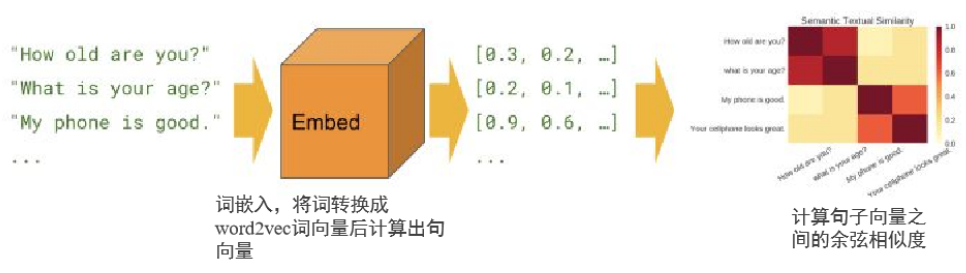

#### 5.3.3 基于深度学习的有监督文本语义匹配
**方法分类：**

- Representation-based(基于表示的模型)：DSSM、CDSSM、CNTN、DSSM—LSTM
- Interaction-based(基于交互的模型)：ARC-II、MatchPyramid、DecAtt、ESIM

#### 5.3.4 Representation-based(基于表示的模型)
**模型框架：**

- 这类方法是先分别是学习出query和doc的语义向量表示，然后用两个向量做简单的cosine（或者接MLP也可以），重点是学习语义表示(representation learning)。

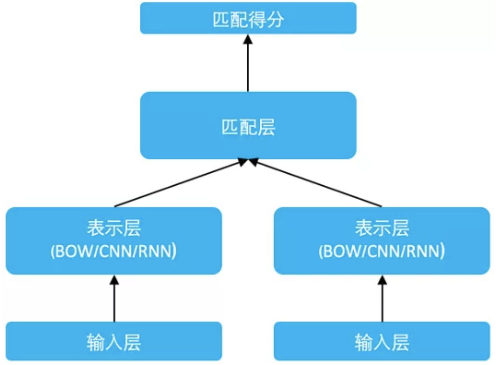  
基于表示的模型架构

**这种方法的模型分两个步骤：**

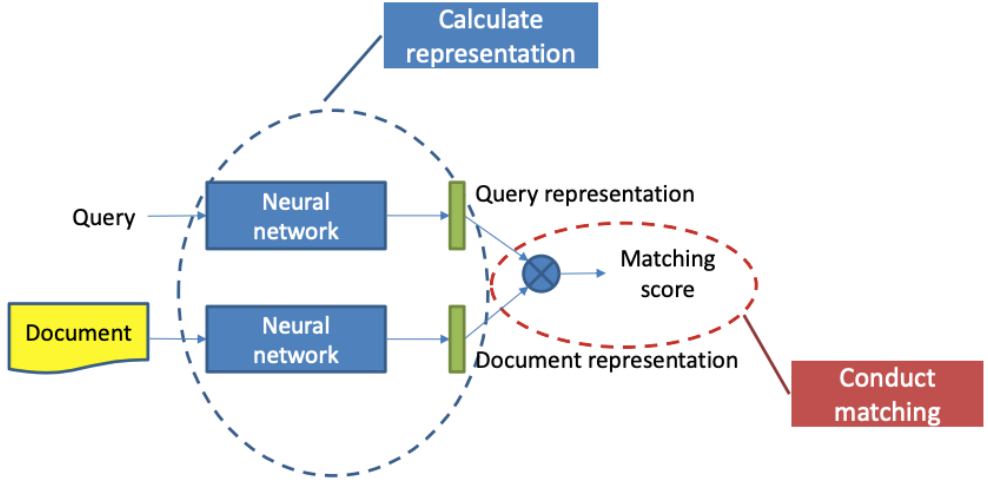

- （1） 表示层：计算query和doc各自的representation，如图中蓝色圈所示
- （2） 匹配层：根据上一步得到的representation，计算query-doc的匹配分数，如图中红色圈所示

##### 1.Deep Structured Semantic Model (DSSM)：
DSSM模型全称是deep struct semantic model，是微软在2013年提出来的深度匹配模型，后续一举成为表示学习的框架鼻祖，语义匹配的开山之作。这个模型，用MLP来分别学习query和doc的语义向量表示  
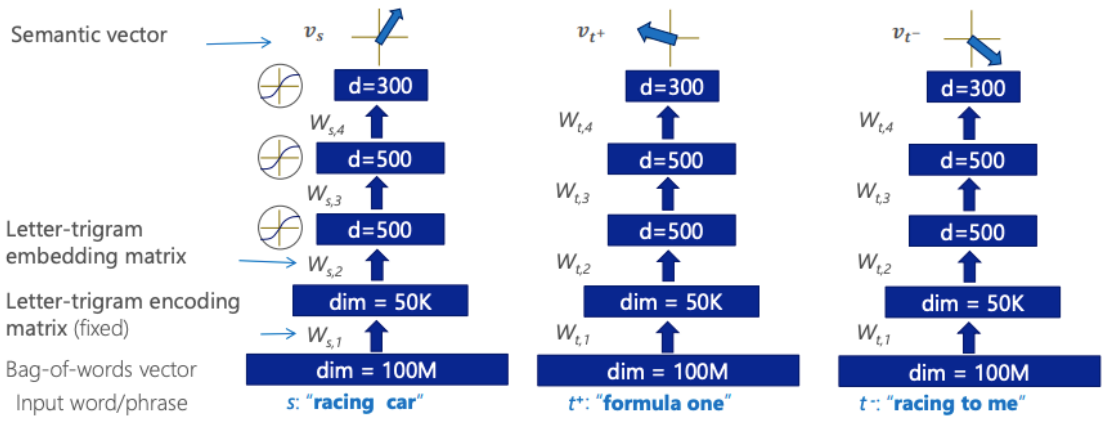
- 首先，模型使用letter-trigrams，即letter级别的trigram来表示词（即在每个单词前后插入一个#，然后使用每一个letter-trigrams来表示单词）：
    - “#candy# #store#” --> #ca can and ndy dy# #st sto tor ore re#
- Representation: [0, 1, 0, 0, 1, 1, 0, …, 1]
    - 将每一个letter-trigram映射成一个d维的向量
- 将query内所有的letter-trigram的向量相加得到一个d维的向量（bag of words，词袋模型）；因为是相加，忽略了顺序，所以是词袋模型；相加还有一个作用是，将变- 长的向量转化为定长
- 将doc内所有的letter-trigram的向量相加得到一个d维的向量（bag of words，词袋模型）
- 后续继续接几个FC来分别学习query和doc的语义向量
- 然后用query和doc的语义向量的cosine表示它们的相似度打分

**损失计算：**

- dssm的loss function: point-wise的loss，例如log-loss，即和ctr点击率预估一样，相关的文档的label为1，不相关的文档的label为0

**使用bag of letter-trigrams的好处:**

- 减少字典的大小，#words 500K -> letter-trigram: 30K
- 减缓out of vocabulary的问题，提高了泛化性
- 对于拼写错误也有一定的鲁棒性

**dssm的缺点:**

- 词袋模型，失去了词序信息
- point-wise的loss，和排序任务match度不够高（排序任务一般是pairwise）。
- 可以轻松的扩展到pair-wise的loss，这样和排序任务更相关。
- 那么怎么获取词序信息呢？答案是可以使用CNN和RNN。

##### 2.CDSSM模型：

- DSSM模型的输入是query和doc的词袋模型生成的向量，所以模型丢失来文本的上下文结构信息。而CDSSM模型则通过词的n-gram和卷积池化操作来捕获上下文关系，按文章说明的，该算法相比原始DSSM将近会有10%的效果提升。  
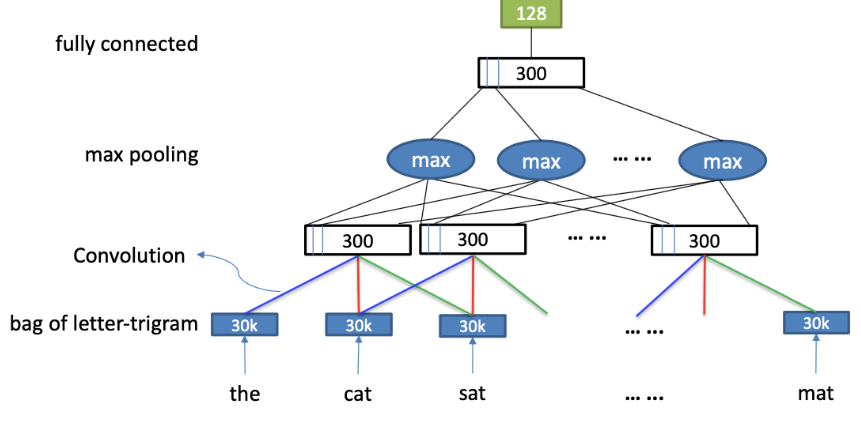

CDSSM模型流程：

- 首先，模型使用letter-trigrams，即letter级别的trigram来表示词（即在每个单词前后插入一个#，然后使用每一个letter-trigrams来表示单词）：
    - “#candy# #store#” --> #ca can and ndy dy# #st sto tor ore re#
- Representation: [0, 1, 0, 0, 1, 1, 0, …, 1]
    - 将每一个letter-trigram映射成一个d维的向量
- 使用CNN卷积网络提取上下文局部特征
- 在时序维度上做maxpooling得到300维向量
- 经过全连接映射得到128维文本表示向量

**使用CNN或者RNN替代DNN**

- CNN提取文本顺序信息：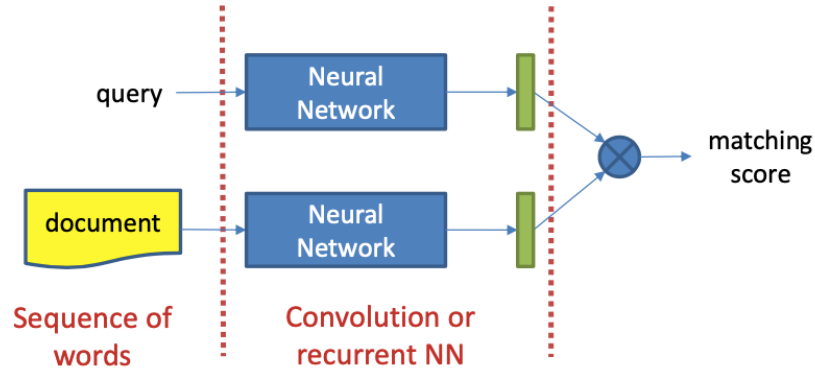
- 1d-CNN和pooling操作可以保持文本的局部信息:  
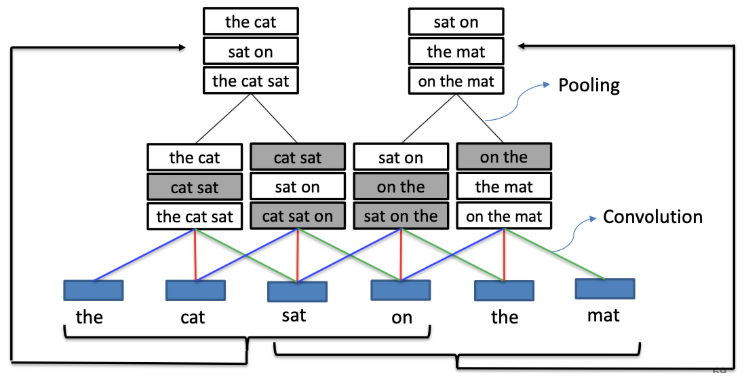

**CNN提取文本顺序信息过程：**

CNN对文本建模的常见操作，以CNN如何获得一个句子的向量为例：
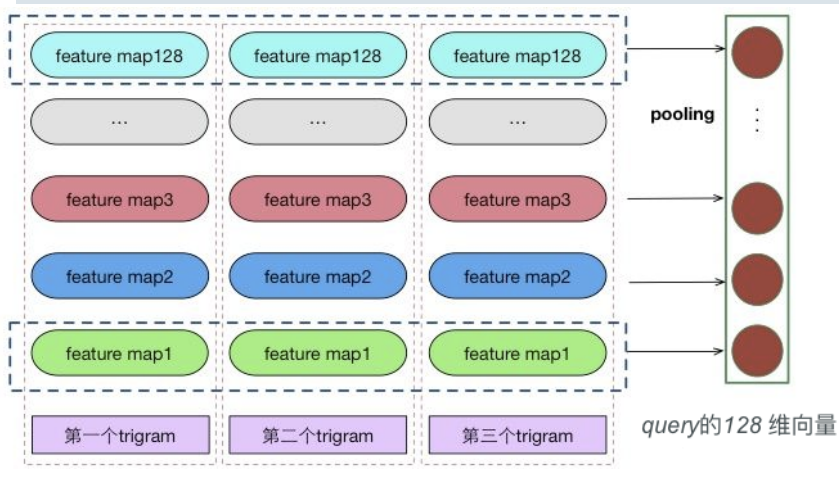

> - 假设输入句子是sen=[A B C D E]，每个单词映射成一个100维的向量
> - 假设卷积核窗口大小为k=3，那么每次对3个单词的向量（concat，得到3*100的一个300维的向量）进行卷积，卷积结果得到一个值，类似以下过程：
>   - $out_1 = w_1x_1 + w_2x_2+.....w_{300}*x_{300}$
> - 那么依次对ABC、BCD、CDE进行卷积，就会得到三个值: $out_1,\; out_2,\; out_3$
> - 对 $out_1,\; out_2,\; out_3$取最大值， 即所谓的max-pooling，就会得到一个值，不妨叫max_out_1
> - 上面是只有一个卷积核的情况，如果我们使用128个卷积核，就会得到128个值，这128个值就可以当成句子的向量

##### 3.CNTN模型：

- 前面提到的CNN-DSSM模型核心在于表示层上引入了CNN模型结构，对匹配层依然是沿用了DSSM的cosine来计算query和doc的匹配分数。而在IJCAI2015年提出的Convolutional Neural Tensor Network，简称CNTN模型，除了一样在表示层引入CNN学习query和doc的表示，另外也在匹配层做了改造，引入了Neural Tensor Network，整体框架表示如图所示

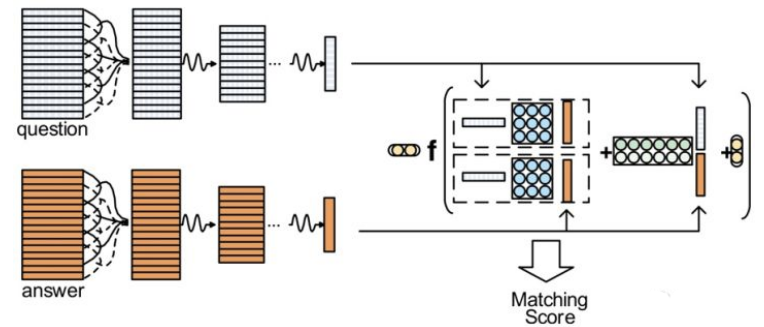  
使用DNN进行相似度计算

**CNTN模型的匹配分数计算：**

- 对于给定的query和doc，从表示层已经得到各自的表示q和d，在匹配层引入了neural tensor network，也就是更多的网络参数来学习q和d的匹配分数，用公式表示如下：

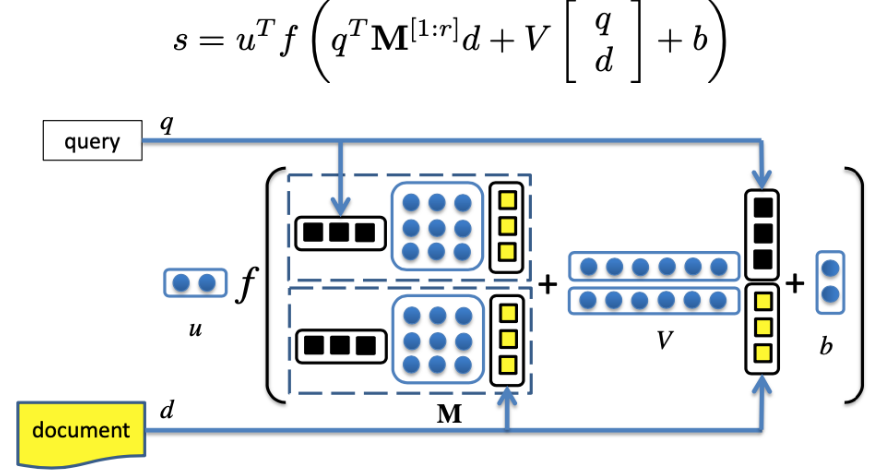

> 其中：query 的表示 $q$ 和 doc 的表示 $d$ 都是 $n$ 维（图中为 3 维）向量，$q$ 为图中的黑色部分，$d$ 为黄色部分。$M^{[1:r]}$ 是 $q$ 和 $d$ 之间的 $r$（图中等于 2）个 $n \times n$（图中为 $3 \times 3$）转换矩阵（张量）。因此，双线性计算部分 $q^T M^{[1:r]} d$ 产生的是一个 $r$ 维度的向量，在图中就是 2 维向量。公式的第二部分，$V$ 是一个 $2n \times r$（图中为 $6 \times 2$）的矩阵，乘以 $q$ 和 $d$ 两个向量 concat 一起的向量（即 $\begin{bmatrix} q \\ d \end{bmatrix}$）后，也得到一个 $r$ 维（2 维）向量，再加上一个维度为 $r$ 维（2 维）的 bias 向量 $b$。通过中间括号的操作得到一个 $r$ 维（2 维）的向量后，引入了非线性函数 $f$ 进行拟合，再通过最外侧一个线性矩阵（或向量）$u$ 的映射，最终得到匹配分数 $s$。

**使用RNN保持文本局部顺序信息：**

- RNN可以很好的对序列进行建模，保留序列信息。每个timestamp喂入一个词的embedding，那么最后一个time_stamp的隐状态就可以当成整个句子的语义表示向量，然后正反向rnn一起用的话，效果有很好的提升：

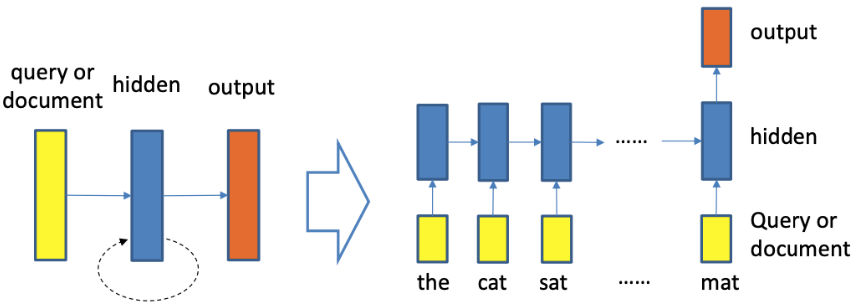  
单向或者双向RNN也能够提取文本局部上下文信息

##### 4.DSSM—LSTM模型

- 相比DSSM只是把MLP（Multi-layer nonlinear projection）换成了RNN

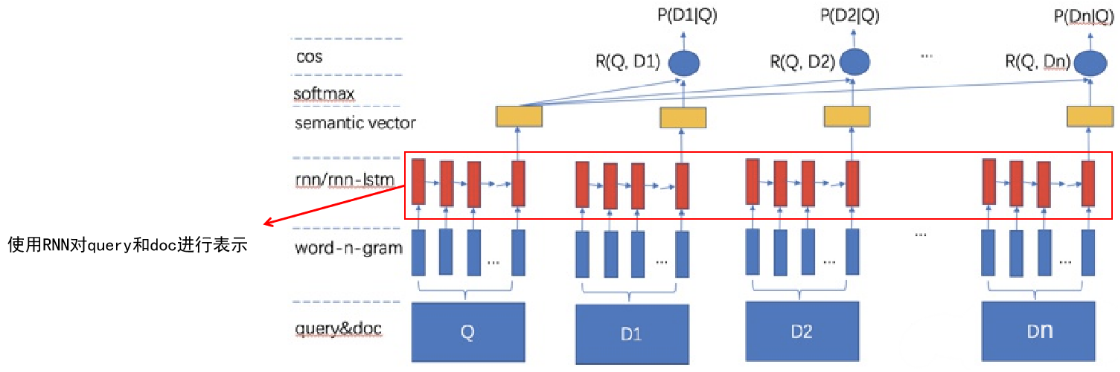

**matching function**

得到query和doc的向量表示后，可以由以下几种方式得到它们的语义匹配分:
- consine: $s = \frac{q^T d}{\lVert q \rVert \cdot \lVert d \rVert}$ 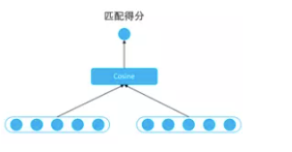
- 内积:$s = q^T d$
- 接一个或者多个MLP，最后一层的输出层只有一个节点，那么最后一层的输出值就可以表示匹配分:$s = W_2 \cdot \sigma\left( W_1 \cdot [q; d] + b_1 \right) + b_2$

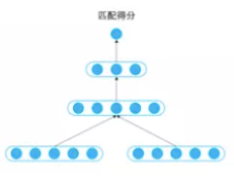

**Loss function**

得到query和doc的向量表示后，可以由以下两种损失函数来进行分类处理:

- 执行二分类，判断输入是不是属于同一类
    - L=−ylogp+(1−y)log(1−p)
    - 其中，L是损失函数，y 是类别标签0,1，p 是预测的概率值。为了训练网络以区分相似和不相似地对象，可以一次提供一个正例和一个负例，并对损失进行加和
- 使用triplet loss:
    - L=max(d(a,p)−d(a,n)+m,0)
    - 其中，d 是距离函数，如L2损失；a是数据集中的一个样本，p 是一个随机正样本，n 是一个负样本，m 是阈值。通过最小化上述损失函数，a与p之间的距离 $d(a, p) = 0$，而 a 与 n 之间的距离 $d(a, n)$ 大于 $d(a, p) + \text{margin}$ 。当negative example很好识别时，上述损失函数为0，否则是一个比较大的值

**多形式结合使用**

- 使用欧式距离和余弦距离进行表达,然后使用MLP映射,最终做二分类

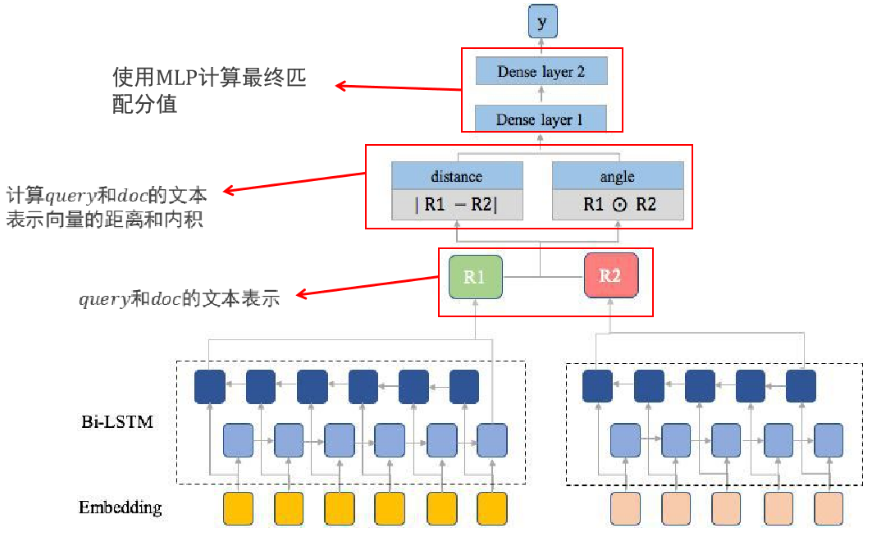

**基于表示的模型小结**

- 两个步骤:
    - 计算查询文档q和目标文档d的文本表示向量
    - 根据向量计算相似度
- 表示层
    - DNN框架：DSSM模型
    - CNN框架：CNN-DSSM模型、CNTN模型
    - RNN框架：LSTM-RNN模型
- 匹配层
    - 余弦相似度(内积)
    - MLP映射
    - Neural Tensor Network：CNTN模型
- 损失函数
    - 二分类损失（(a,p,1),(a,n,0)）
    - triplet loss((a,p,n)) 做排序任务

#### 5.3.5 Interaction based (基于交互的模型)
**基于交互的模型原理**

- 对比representation learning的深度匹配模型，Interaction based方法的特点，是不直接学习query和doc的表示，而是一开始就让query和doc进行各种交互，通过两者交互的match signals进行特征提取，然后通过aggregation对提取到的match signals用各种网络结构进行学习得到最终的匹配分数，如图所示。

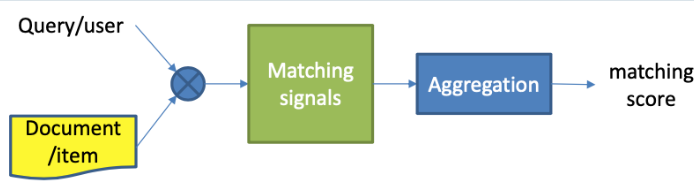

**基于交互的模型计算过程**

和representation learning匹配模型一样，Interaction based的匹配过程也一样可以分为两步：

- 基础匹配信号提取：让query和doc在这一步就开始进行交互，得到两者的基础匹配信号，如图中的蓝色圆圈所示
- 信号聚合（aggregation）：对应于representation learning中的匹配层，这里也叫匹配层，由于前一步已经进行了query和doc的交互，信号更加丰富，在后面介绍的模型中可以发现匹配层这里也会比表示学习的网络结构设计变化要丰富很多

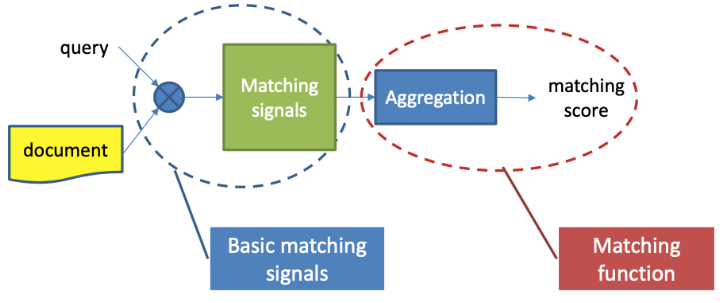

##### 1.基于phrase-level匹配度矩阵的模型：ARC-II模型
- 基于Interaction based的模型和representation learning的模型最大的区别是让query和doc提前进行交互，因此很多模型的工作就是关于如何设计query和doc的交互上。一种很直观的思路就是，让query和doc两段文本里面每个word两两进行交互，在word level级别建立匹配度矩阵。
- ARC-II全称Architecture-II，和ARC-I出自2015年华为的同一篇paper，属于交互学习的模型。ARC-I直到最后的全连接层进行匹配之前，query和doc两段文本都是没有任何交互的，大家都在各自学习各自的表示。而ARC-II模型属于交互学习的模型，通过对query中的word进行n-gram的卷积提取，以及doc中的word进行卷积提取，然后各自卷积后得到的词向量进行pairwise计算，得到一个匹配度矩阵，整体框架如图所示

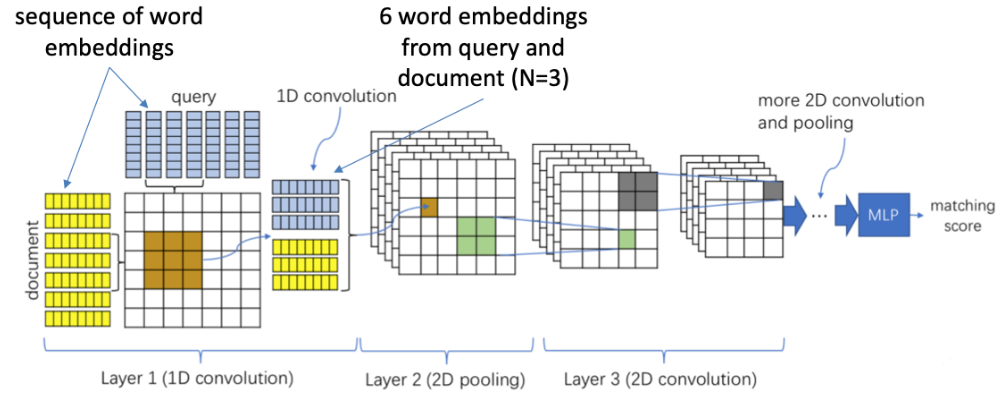  
在提取匹配度矩阵过程中，核心有3层：一维卷积层、二维卷积层和二维池化层

**ARC-II模型匹配过程：一维卷积层**

- 假设query和doc的长度都是N，我们把整个过程想象类比层二维图像，让query和doc的每个word两两组成一个N∗N的矩阵，query是列，doc是行。。其中每个word的embedding维度是D。
- 用一个$$3\times 3 \text{ 的卷积核在 } N \times N \text{ 的矩阵上进行扫描，每次横向扫描 } $$
$$3 \text{ 个格子，纵向扫描 } 3 \text{ 个格子，代表在 query 和 doc 上对应的 } 3 \text{ 个相邻的词，总共取到 } $$
$$6 \text{ 个词进行 concat，可以得到一个 } 6 \text{ 维向量。}$$

$$\text{卷积核大小也为 } 6 \text{ 维，两者进行点乘相加得到一个值。}$$
$$\text{这样扫描完整个 } N \times N \text{ 矩阵，就可以得到一个二维的矩阵 feature\ map。}$$
$$\text{使用多个卷积核，就可以得到多个二维矩阵 feature\ maps。}$$
- 通过这种 $\text{tri-gram}$ 的方法（每次取3个词）的交互，可以得到query和doc中任意3个相邻的word组成的短语的交互关系，因此交互级别属于phrase级别的。对于query中的第i个word，和doc中的第j个word，卷积后的表示为∶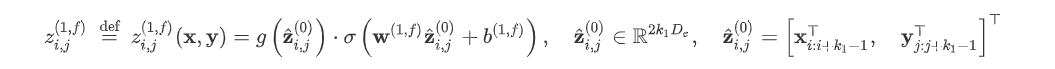 -注意到第一层的元素 $\hat{z}_{i,j}^{(0)}$ 当于将输入x和y的向量concat了起来，embedding维度为$D_e$

**ARC-II模型匹配过程：2维池化层**

- 一维卷积层保留了query和doc中每个词的原始信息。在2维的池化层作用是用一个2 * 2的卷积核，用max - pooling得到这4 个二维空间的最大值

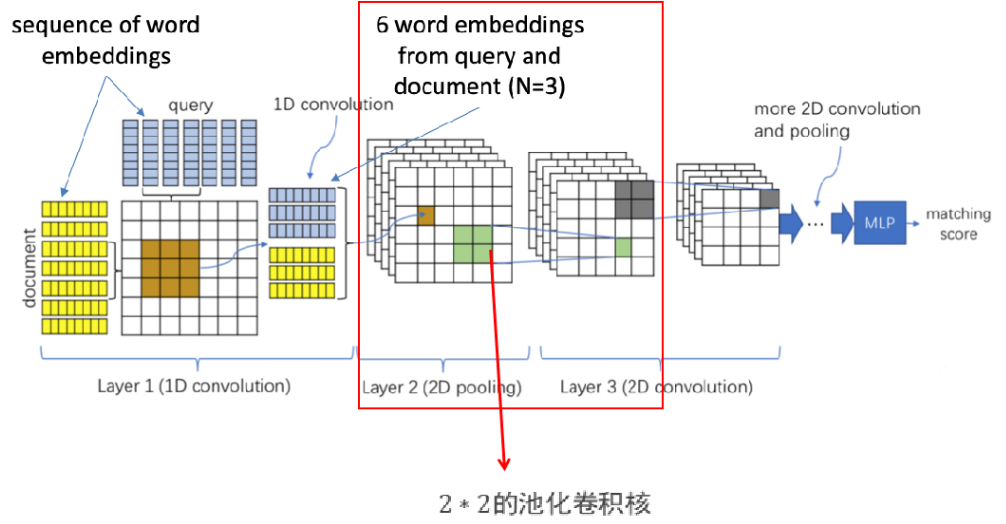

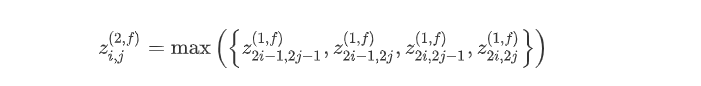

**ARC-II模型：2维卷积层**

- 前面通过一维卷积层和max-pooling后得到的是2维的匹配矩阵，接着的操作可以类比于图像，在二维的平面上进行多层的卷积-池化-卷积-池化…的操作了。以第三层为例（前面已经有两层∶一维卷积-二维池化），在一个二维平面做卷积

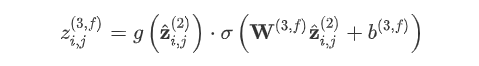

- 2维券积层之后可以叠加多个卷积和池化的操作.最后再通过全连接MP输出最终的匹配分数。

损失函数使用pairwise loss

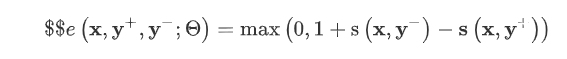

在整个2维卷积和池化过程，可以发现word的顺序关系是有所保留的，如图所示的2维度池化过程，max-pooling 选择的黄色方块保留了原始的order信息。

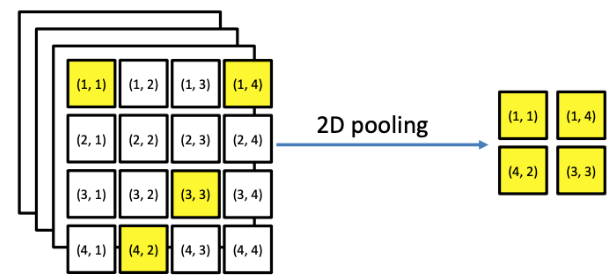

**ARC-II模型特点**

- 对比ARC-I，在一开始就引入了query和doc两段文本的匹配矩阵，提前得到两者的交互信息，对信息匹配的捕捉能力更强，并且卷积和池化过程保留了次序的信息
- 虽然引入了query和doc的匹配矩阵，但是匹配矩阵的计算是按照每个句子的n-gram后的word embedding计算，只有phrase level的匹配信号而没有更细粒度的word level的匹配信号，因而丢失了原始精确匹配和泛化匹配的信息。

##### 2.基于word level匹配度矩阵的模型- MatchPyramid模型
- 前面提到的ARC-II模型引入了匹配矩阵，但是匹配的粒度是n-gram后提取各自的word embedding进行计算，并不是word-level级别的。而MatchPyramid模型的提出灵感源于CV领域里的图像识别。
- 在此之前，文本匹配的维度是一维的（TextCNN为代表的word embedding）;而图像是二维平面的，显然信息更加丰富。2016年的AAAI上中科院提出了基于word-level级别交互的矩阵匹配思想，用一个二维矩阵来代表query和doc中每个word的交互，相比于更高level的匹配如ARC-II的phrase level（n-gram）信息能捕捉更精细的匹配信息，属于真正word level的匹配度矩阵，整体框架如图所示:  
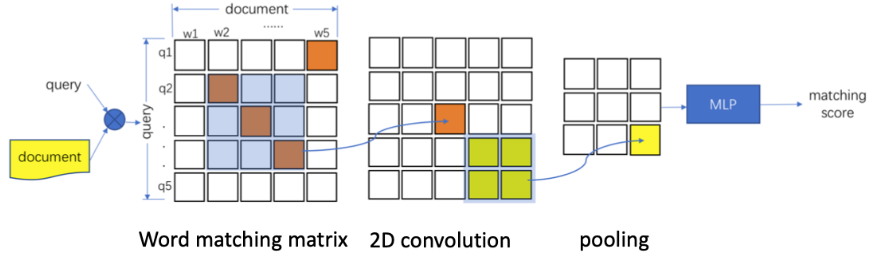

**word-level和phrase-level比较**

- 以下图两个例子说明下word-level的匹配以及phrase-level的匹配的不同:

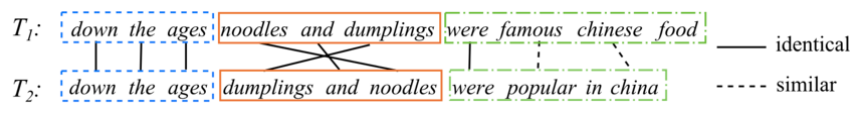

- 对于word-level的匹配能捕捉到更细粒度的信息，例如橙色方框中能捕捉到famous对应popular以及Chinese对应China这样的匹配信息。
- 对于phrase-level的短语匹配又可以分为n-gram有序的短语，以及n-term无序的短语。图中显示的是tri-gram也就是3个词一个窗口，同颜色的方框是匹配的。对于n-term的匹配，方框中第一个句子中的“down the ages”和第二个句子中的”down the ages”是匹配的。对于n-gram的匹配，橙色方框中第一个句子中的”noodles and dumplings”和第二个句子中的”dumplings and noodles”通过tri-gram后打乱了词序信息后是匹配的。

**MatchPyramid模型架构**
- 整个MatchPyramid模型框架如图所示：

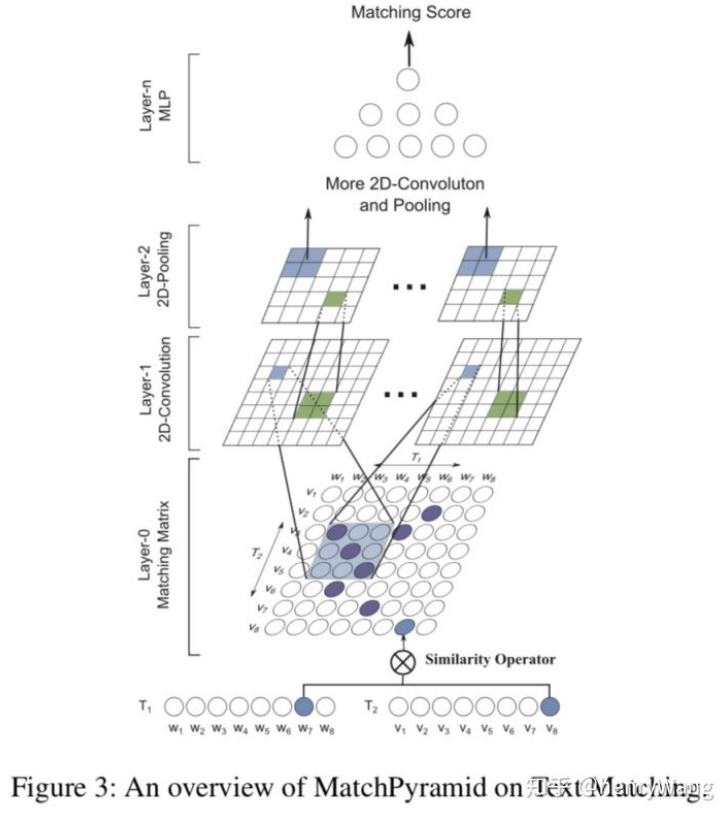  
关键在于如何构建query和doc中word级别的匹配信息，整体框架可以分为3层，匹配矩阵层、2维卷积层、2维池化层，后续卷积和池化可以持续进行叠加

**MatchPyramid模型：匹配矩阵层**

匹配矩阵的构造是MatchPyramid模型的核心关键。用M矩阵代表query和doc的匹配，$M_{ij}$ 为矩阵的第i行第j列，表示第一个句子query中第i个单词和第二个句子doc中第j个单词的交互。这里对于 $M_{ij}$ 如何构造，有3种方法，indicator、cosine以及dot product，分别如下

- a) indicator match 0-1匹配矩阵，只有两个word完全相同才等于1，否则为0，相当于是精确匹配

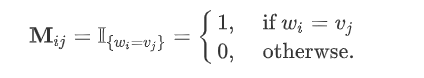

- b) cosine match 将每个word用glove预训练得到的词向量，两两计算cosine相似度 $M_{ij} = \frac{\vec{\alpha}_i^{\top} \vec{\beta}_j}{\lVert \vec{\alpha}_i \rVert \cdot \lVert \vec{\beta}_j \rVert}$

- c) dot product match 将每个word用glove预训练得到的词向量，两两计算向量点积
$M_{ij} = \vec{\alpha}_i^{\top} \vec{\beta}_j$

- 下图显示了indicator和dot product两种：  
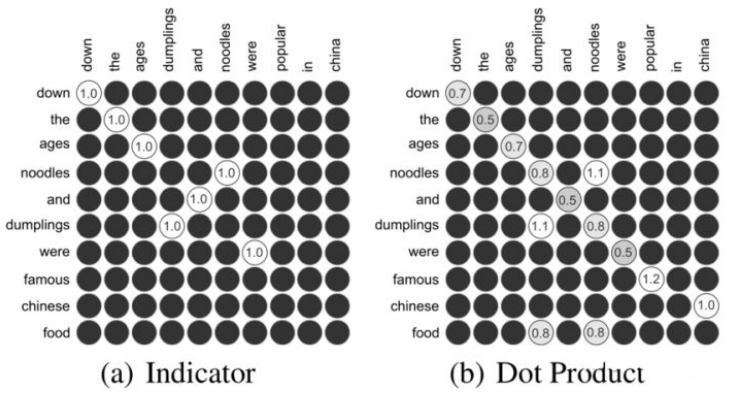  
> 黑色部分是0；dot product或者cosine对比indicator能捕获到更多的泛化信息，例如在indicator对于famous和popular的匹配分数是0，而用dot product得到两者的匹配分数是1.2

**MatchPyramid模型∶二维卷积层**

以第一层为例，通过一个 $r_k \cdot r_k$ ，的卷积核提取二维匹配矩阵的信息，相当于是提取query和doc在各自连续 $r_k$ 个word 的信息交互

**MatchPyramid模型∶二维池化层**

以第一层的池化层为例，在 $d_k \cdot d_k$，的kernel写用max-pooling求最大值

**MatchPyramid模型理解**

- 以下这张图展示了使用indicator match的MatchPyramid模型和图像识别中一些相似的匹配过程 

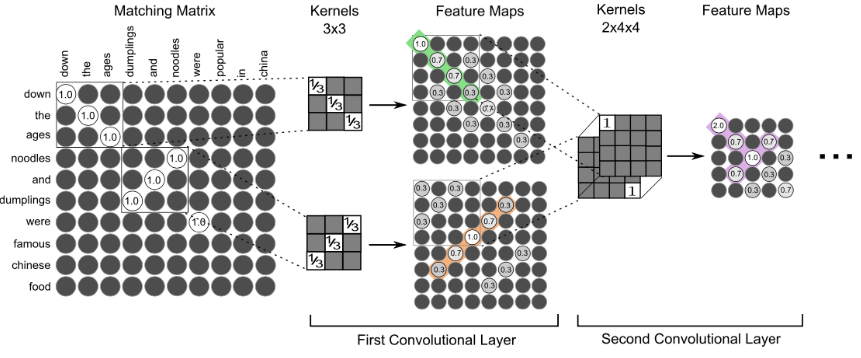

> 左边用indicator match得到两个句子的相似匹配矩阵，相当于是精准匹配，第一层卷积层通过上下两个对角线以及反对角线的卷积核之后，可以得到两个feature map，第一个feature map的绿色部分和第二个feature map的橙色线条类似于图像识别中的边缘检测。通过第二层的卷积核之后，可以得到右侧的feature map中的紫色的“T-type”的part，这一部分类比于图像识别中的motifs(part)识别。

- 以下这张图展示了使用dot product match的MatchPyramid模型和图像识别中一些相似的匹配过程

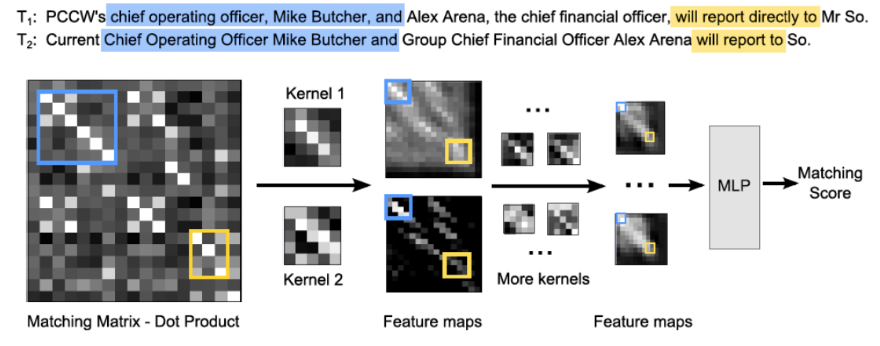

> 左边用dot product得到两个句子的相似匹配矩阵，第一层卷积层通过上下两个对角线的卷积核之后，可以得到两个feature map，两个feature map中的蓝色框代表了两个句子蓝色部分匹配特征，黄色框代表黄色部分匹配特征。通过第二层的卷积核之后，依然可以提取出两部分的匹配特征

**MatchPyramid模型特点**

- （1） 比起ARC-II模型通过n-gram得到的word embedding进行相似度计算，MatchPyramid模型在匹配矩阵的计算上做得更加精细，关注的是原始word级别的交互
- （2） 对于query和doc之间每个word的两两交互提出了3中方法，包括精确匹配的indicator计算，两个word完全相同为1否则为0；以及语法相似度的匹配，包括cosine以及dot product，关注的是更泛化的匹配
- （3） 整个过程和图像识别以及人类的认知一样，word-level的匹配信号，类比图像中的像素特征；phrase-level的匹配信号，包括n-gram有序的phrase以及n-term无序的phrase，类比图像中的边缘检测；到sentence-level的匹配信号，类比图像中的motifs检测

##### 3.基于attention的模型-- DecAtt模型
- 基于word level的匹配度矩阵可以说是整个基于match function learning模型的标配组件，而这有这种low level的匹配矩阵信息基本是不够的，在当前attention机制在整个NLP领域随处可见的情况下，attention也基本成了后续众多模型的标配组件之一。

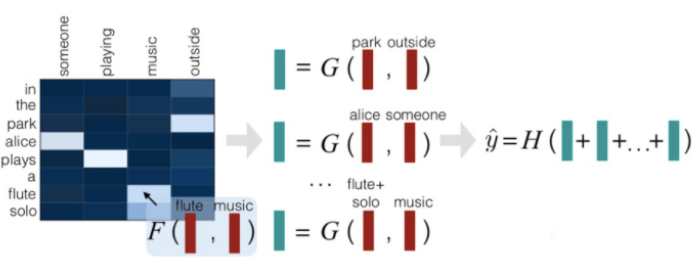

> EMNLP 2016提出的Decomposable Attention Model，简称DecAtt模型，是较早在query和doc的关系建模上引入attention机制的。该模型将两个句子通过分解（decompose）成每个word的软对齐机制，来计算当前文本query（doc）中每个word与另一段文本doc（query）的attention得到每个word的加权向量，然后通过当前word的原始向量与attention加权向量的compare，最终对交互得到的向量进行aggregate得到最终的匹配分数，整体框架如图所示

**DecAtt模型步骤**

输入∶ query和doc各自有 $I_a$ 和 $I_b$ 个 term 组成，每个term是个定长的embedding向量：
$$\bar{a} = (\bar{a}_1, \dots, \bar{a}_{\ell_a}), \quad \bar{b} = (\bar{b}_1, \dots, \bar{b}_{\ell_b})$$
整个模型可以分为3步∶

- ①attend∶ 用attention机制看成 soft - align 对齐过程，得到query和doc中每个word的加权向量(subphrase)
- ②compare∶ 把每个 word 的加权向量 subphrase，与原始的向量进行 compare 通过一个前向网络拟合，作为query 的最终向量以及doc的最终向量
- ③aggregate∶通过一个神经网络H 去捕捉query和doc的向量，得到匹配分数。在该 paper中是个分类问题，因此使用的是交叉熵作为损失函数

**DecAtt模型步骤—∶attend**

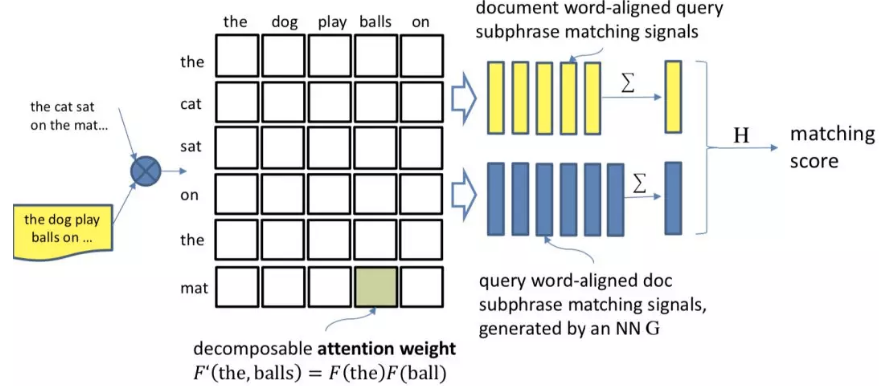

论文中将 attention 机制看成—种软对齐机制（sol1-align），将query中第i个word与doc中每个word分别求权重，然后加权求和，就可以得至query中的第i个 word 跟doc的对齐向量 $\beta_i$ ；同理可以得到doc向 b 中第j个word的对齐向量 $\alpha_j$

$$\beta_i := \sum_{j=1}^{\ell_b} \frac{\exp(e_{ij})}{\sum_{k=1}^{\ell_b} \exp(e_{ik})} \, \bar{b}_j,\quad
\alpha_j := \sum_{i=1}^{\ell_a} \frac{\exp(e_{ij})}{\sum_{k=1}^{\ell_a} \exp(e_{kj})} \, \bar{a}_i$$
> 其中，$e_{ij}$ 为query向量 a 的第i个term和doc向量 b 的第j个term的归一化前的权重：
$$e_{ij} := F'( \bar{a}_i, \bar{b}_j ) := F( \bar{a}_i )^T F( \bar{b}_j )$$
> $F$ 是普通的神经网络并经过 ReLU 激活。如果直接使用 $F'$ 函数，复杂度为 $I_a I_b$。
而先用 $F$ 函数拟合 query 和 doc 各自的表达，则 $F$ 只需要计算次数为 $I_a+I_b$。  
原始复杂度：$$O(I_a I_b)$$  优化后复杂度：$$O(I_a + I_b)$$  其中交互矩阵定义为：$$e_{ij} := F'(\bar{a}_i, \bar{b}_j) := F(\bar{a}_i)^T F(\bar{b}_j)$$

**DecAtt模型步骤二∶compare**

- 从①可以得到 query 向量a和doc向量b中每个word的权重 $\beta_i$ 和 $\alpha_j$，通过函数 G 就可以得到各自的对齐（soft-align）表达，这里 G用的是MLP全连接网络∶  
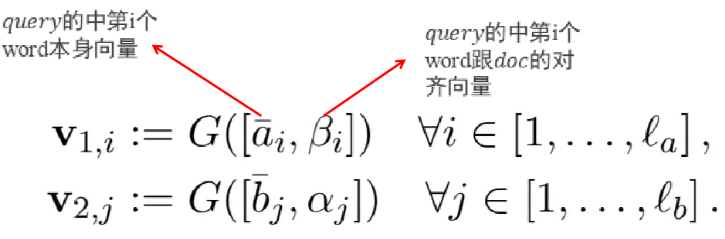

**DecAtt模型步骤三：aggregate**

- 得到每个word的对齐表达后，最终的句子为每个word直接sum得到：
$$v_1 = \sum_{i=1}^{\ell_a} v_{1,i},\quad v_2 = \sum_{j=1}^{\ell_b} v_{2,j}.$$
- 这里将文本匹配看成分类问题，因此后面使用一个线性分类器进行分类
$$\hat{y} = H\left([v_1, v_2]\right)$$
- 损失函数使用 crossentropy 损失函数：
$$\mathcal{L}(\theta_F, \theta_G, \theta_H) = \frac{1}{N}\sum_{n=1}^{N}\sum_{c=1}^{C}y_c^{(n)}\log\left(\frac{\exp(\hat{y}_c)}{\sum_{c'=1}^{C} \exp(\hat{y}_{c'})}\right)$$

##### 4.基于attention的模型--ESIM 模型
ESIM 模型在众多短文本匹配比赛中大杀四方，表现十分出色。ESIM 模型全称为"Enhanced Sequential Inference Model"，增强序列推断模型，是加强版的 LSTM。论文中解决的虽然是 premise 和 hypothesis 的关系，但是我们可以应用到 query 和 doc 或者其他两段文本关系之中。对比以往传统的 LSTM 模型非常复杂的网络设计，ESIM 模型通过精细的序列式网络设计，以及同时考虑局部推断和全局推断的方法来达到更好的效果。整体框架如图所示。

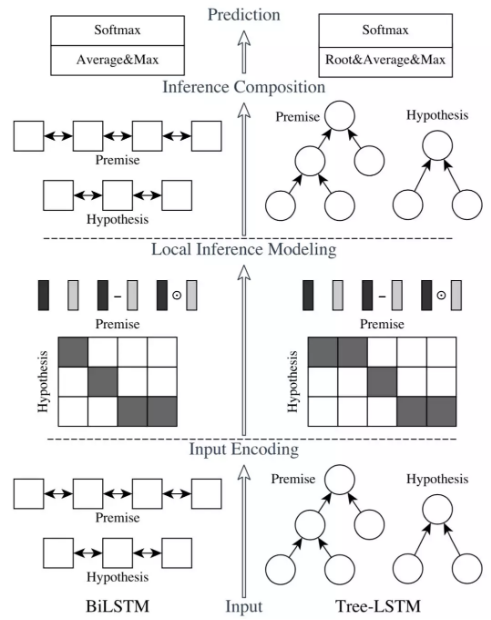

整个模型结构主要有 3 部分：

- ① input encoding 层；
- ② 局部推理层；
- ③ 推理组合层。

**ESIM 模型：input encoding之BiLSTM**

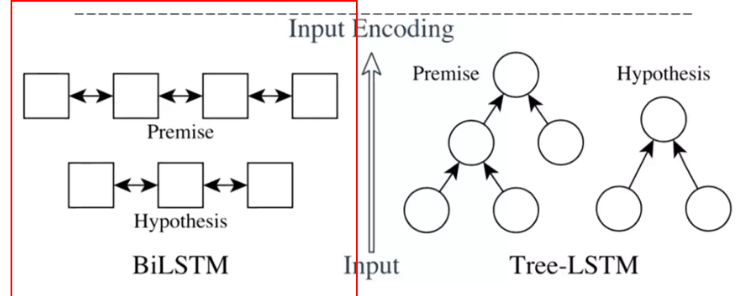

- 对于给定的两个句子 a 和 b (代表前提 premise 和假设 hypothesis)，分别由 $I_a$ 和 $I_b$ 个word组成，其中每个 word 为维度为 n 的 embedding 向量，一般由预训练得到：
$$a=(a_1,\dots,a_{\ell_a}),\ b=(b_1,\dots,b_{\ell_b})$$
- 作者使用双向 LSTM 作为基础模块，用 $a_i$ 表示句子 a 中第i个时刻的隐藏层输出，用 $b_j$ 表示句子b中第j个时刻的隐藏层输出，表示如下：
$$
\bar{a}_i = \operatorname{BiLSTM}(a, i),\ \forall i\in[1,\dots,\ell_a],\qquad
\bar{b}_j = \operatorname{BiLSTM}(b, j),\ \forall j\in[1,\dots,\ell_b]
$$

**ESIM 模型：input encoding之Tree-LSTM**

除了常规的 Bi-LSTM 之外，文中还使用了 Tree-LSTM 来捕捉序列关系。在每个 t 时刻，具体结构如下：

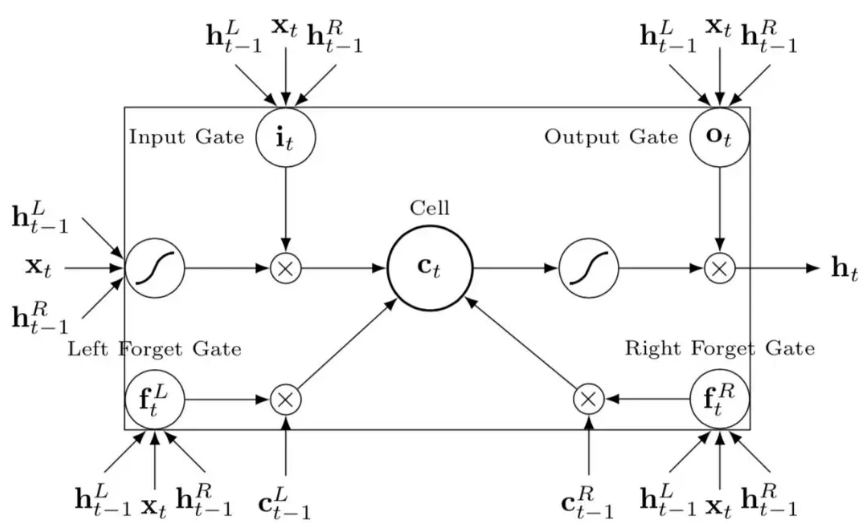

- 当前输入除了 $x_t$ ，还有前一时刻的隐层输入 $h_{t-1}$ 的左右叶子结点 $h_{t-1}^L$ 以及 $h_{t-1}^R$
- 输入门 input gate 以及输出门 output gate 依然只有一个，两个门的输入都包括当前输入$x_t$、前一时刻隐层$h_{t-1}$的两个叶子结点$h_{t-1}^L$ 和 $h_{t-1}^R$
- 遗忘门 forget gate∶ 和传统的LSTM不同，有两个，分别是 left forget gate 和 right forget gate，输入和前面两个门一样，分别是当前输入$x_t$、前一时$h_{t-1}^L$ 和 $h_{t-1}^R$ 。细胞状态∶输入来自前一时刻细胞状态左右两个节点$c_{t-1}^L$ 和 $c_{t-1}^R$。而左右两个遗忘门 forget gate分别控制需要左右两个细胞状态需要保留的信息。
- 整体的公式表达如下所示:
$$
\begin{aligned}
h_t &= \operatorname{TrLSTM}(x_t, h_{t-1}^L, h_{t-1}^R), \\
h_t &= o_t \odot \tanh(c_t), \\
o_t &= \sigma\!\left(W_o x_t + U_o^L h_{t-1}^L + U_o^R h_{t-1}^R\right), \\
c_t &= f_t^L \odot c_{t-1}^L + f_t^R \odot c_{t-1}^R + i_t \odot u_t, \\
f_t^L &= \sigma\!\left(W_f x_t + U_f^{LL} h_{t-1}^L + U_f^{LR} h_{t-1}^R\right), \\
f_t^R &= \sigma\!\left(W_f x_t + U_f^{RL} h_{t-1}^L + U_f^{RR} h_{t-1}^R\right), \\
i_t &= \sigma\!\left(W_i x_t + U_i^L h_{t-1}^L + U_i^R h_{t-1}^R\right), \\
u_t &= \tanh\!\left(W_c x_t + U_c^L h_{t-1}^L + U_c^R h_{t-1}^R\right).
\end{aligned}
$$
> 其中$W_f, W_i, W_c, W_o$是一个 dl 的待训练参数；U 是 dd 的待训练参数矩阵。这样，原始的两个句子输入通过 word embedding 之后，通过左边一个BiLSTM，右边一个 tree-LSTM编码之后输入到下一层网络

**ESIM 模型：局部推理层 local inference modeling**

- 在很多相关性模型中，都使用硬对齐或者软对齐的方式来建立query和doc的关系。在前面 DecAtt 模型中就是用 attention 机制来建立 soft-align 软对齐。而在 ESIM 模型中，作者延续使用了 DecAtt 的软对齐方式，对于给定的query句 a，以及 doc 句 b，建立两个句子之间每个 word 两两的向量点积作为相似度：
$$
e_{ij} = \bar{a}_i^\top \bar{b}_j
$$
- 在原始的 DecAtt 模型中，作者使用的是例如 MLP来计算$F(a_i)$以及$F(b_i)$进而计算相似度;而在 ESIM 模型中，使用的是LSTM和 tree-LSTM得到两个句子的表示后再计算相似度矩阵。得到 $e_{ij}$ 后，query中第i个word的表示为doc中每个单词的 weight-sum;也就是说 $\tilde{a}_i$ 表示 b 中每个词与 $\bar{a}_i$ 的相关程度。同理，假设句子 b 中第 $j$ 个 word 的表示为句子 a 中每个单词的 weight-sum 表示，$\tilde{b}_j$ 表示 a 中每个词与 $\bar{b}_j$ 的相关程度。公式如下：
$$\tilde{a}_i = \sum_{j=1}^{\ell_b} \frac{\exp(e_{ij})}{\sum_{k=1}^{\ell_b} \exp(e_{ik})} \bar{b}_j, \quad \forall i \in [1, \dots, \ell_a]$$ $$\tilde{b}_j = \sum_{i=1}^{\ell_a} \frac{\exp(e_{ij})}{\sum_{k=1}^{\ell_a} \exp(e_{kj})} \bar{a}_i, \quad \forall j \in [1, \dots, \ell_b]$$
- 得到局部推断后，为了增强信息，分别使用了向量相减、向量点积，最终将 4 个向量 concat 起来，$\mathbf{m}_a$ 和 $\mathbf{m}_b$ 分别表示增强后的 premise 和 hypothesis：
$$\mathbf{m}_a = [\bar{a}; \tilde{a}; \bar{a} - \tilde{a}; \bar{a} \odot \tilde{a}]$$ $$\mathbf{m}_b = [\bar{b}; \tilde{b}; \bar{b} - \tilde{b}; \bar{b} \odot \tilde{b}]$$

**ESIM 模型：推理组合层 (Composition Layer)**
- 通过前一层局部推理建模之后得到的向量 $\mathbf{m}_a$ 和 $\mathbf{m}_b$ 进入当前的推理组合之后，作者依然使用了 Bi-LSTM 和 Tree-LSTM 来捕捉两者关系。对于 Bi-LSTM，公式和第一层 input encoding 的一致，而对于 Tree-LSTM 来说，表示如下：
$$\begin{aligned} \mathbf{v}_{a, t} &= \operatorname{TrLSTM}\left(F\left(\mathbf{m}_{a, t}\right), \mathbf{h}_{t-1}^{L}, \mathbf{h}_{t-1}^{R}\right), \\ \mathbf{v}_{b, t} &= \operatorname{TrLSTM}\left(F\left(\mathbf{m}_{b, t}\right), \mathbf{h}_{t-1}^{L}, \mathbf{h}_{t-1}^{R}\right). \end{aligned}$$
> 这里使用了函数 $F$ 来控制模型复杂度，$F$ 函数作者使用了一层的前向神经网络并且经过 RELU 激活输出。

**ESIM 模型：推理组合层 (Pooling)**
- 通过前面的 composition layer，两个 LSTM 网络编码得到的向量是变长的，query 句子 a 得到一个长度为 $l$ 的向量，doc 句子 b 得到一个长度为 $L$ 的向量，在这层 pooling 层目的是为了得到一个固定长度的向量。
- 为了最大程度捕捉信息，论文中同时使用了 average pooling 和 max pooling，并将两种 pooling 得到的向量 concat 起来，在实验中证明比单纯的 sum pooling 效果要好，公式如下∶
$$\mathbf{v}_{a, \text{ave}} = \sum_{i=1}^{\ell_a} \frac{\mathbf{v}_{a,i}}{\ell_a}, \quad \mathbf{v}_{a, \text{max}} = \max_{i=1}^{\ell_a} \mathbf{v}_{a,i}$$ $$\mathbf{v}_{b, \text{ave}} = \sum_{j=1}^{\ell_b} \frac{\mathbf{v}_{b,j}}{\ell_b}, \quad \mathbf{v}_{b, \text{max}} = \max_{j=1}^{\ell_b} \mathbf{v}_{b,j}$$ $$\mathbf{v} = [\mathbf{v}_{a, \text{ave}}; \mathbf{v}_{a, \text{max}}; \mathbf{v}_{b, \text{ave}}; \mathbf{v}_{b, \text{max}}]$$
> 最终得到的向量 $\mathbf{v}$ 再经过全连接网络后，最后接一个 softmax 输出，训练过程使用多分类的 cross-entropy 损失函数。

**ESIM 模型特点**
- 引入了 Tree-LSTM：是加强版的 LSTM。输入门和输出门都只有一个，输入包括当前输入，以及前一时刻隐层的左右叶子结点；遗忘门有左右两个，每个遗忘门的输入都包括当前输入以及前一时刻隐层的左右叶子结点；细胞状态有一个，输入为前一时刻的左右两个细胞状态。

- 局部推理层的创新：局部推理层中对于匹配矩阵的做法区别于 DecAtt 模型使用 MLP 去提取 query 和 doc 两个句子的做法；而是用两种 LSTM 提取编码后计算加权向量表达。得到加权向量表达后，和原始向量进行乘积和相减后，总共 4 个向量 concat 起来，相当于是丰富了提取到的信息，作为下一层的输入。